In [175]:
#Quinlin Neuhaus HW 4/5
#This code has been adapted from the provided Demo_GRU_2.ipynb

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

torch.manual_seed(0) #Same seeds for reproducibility
np.random.seed(0)

STAGE1, STAGE2, STAGE3, STAGE4 = 0, 1, 2, 3
V = 5 #I hardcoded 4 or 5 later depending on what was needed

def ids_to_str(ids):
    m = {STAGE1:'1', STAGE2:'2', STAGE3:'3', STAGE4:'4'}
    return "".join(m[int(i)] for i in ids)


In [176]:
#I am going to represent the probabilities as a matrix, similar to markov chain representation
# Example matrices (replace with the table from your assignment)

compliantmatrix = np.array([
    [0.81, 0.18, 0.01, 0.00],
    [0.00, 0.89, 0.10, 0.01],
    [0.00, 0.00, 0.95, 0.05],
    [0.00, 0.00, 0.00, 1.00]
])

noncompliantmatrix = np.array([
    [0.78, 0.20, 0.02, 0.00],
    [0.00, 0.77, 0.21, 0.02],
    [0.00, 0.00, 0.79, 0.21],
    [0.00, 0.00, 0.00, 1.00]
])

In [177]:
#Function for making a single patient
def simulate_patient(T=30, compliant=True, rng=None):

    rng = np.random.default_rng(rng)

    stages = np.zeros(T+1, dtype=np.int64)
    stages[0] = STAGE1 #patient start here

    # choose compliance
    if compliant:
        transition = compliantmatrix
    else:
        transition = noncompliantmatrix

    for t in range(T):
        current = stages[t]
        stages[t+1] = rng.choice(4, p=transition[current])

    return stages

In [178]:
#creates all the diabetics
def make_dataset(n=100000, T=30, seed=0):

    rng = np.random.default_rng(seed)

    #First 70k are compliant
    compliance = np.zeros(n)
    compliance[:int(.7*n)] = 1
    rng.shuffle(compliance)

    stages = np.zeros((n, T+1), dtype=np.int64)

    for i in range(n):

        compliant = bool(compliance[i])

        stages[i] = simulate_patient(
            T=T,
            compliant=compliant,
            rng=rng
        )

    #Targets are just the next stage
    x = stages[:, :-1]
    y = stages[:, 1:]

    return x, y, compliance

In [179]:
#Just a test 
x, y, compliance = make_dataset(n=20, T=30)

for i in range(20):
    print("compliant:", compliance[i])
    print("sequence:", x[i])
    print()

compliant: 1.0
sequence: [0 0 0 0 0 0 0 0 0 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]

compliant: 0.0
sequence: [0 0 1 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]

compliant: 1.0
sequence: [0 1 1 1 1 1 1 1 1 1 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]

compliant: 1.0
sequence: [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]

compliant: 1.0
sequence: [0 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3]

compliant: 0.0
sequence: [0 1 1 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]

compliant: 1.0
sequence: [0 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]

compliant: 1.0
sequence: [0 0 0 0 0 0 0 0 0 0 0 0 1 1 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3]

compliant: 1.0
sequence: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 2 2 2 3 3 3 3 3 3 3 3 3]

compliant: 1.0
sequence: [0 0 0 0 0 0 0 0 0 0 1 1 1 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3]

compliant: 1.0
sequence: [0 0 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]

compliant: 1.0
sequence: [0 0 2 

In [180]:
def encode_sequences(stages, compliance):

    N, T = stages.shape

    X = np.zeros((N, T, 5), dtype=np.float32)
    #one hot encoding for the state, last index is compliance
    for i in range(N):
        for t in range(T):

            stage = stages[i, t]

            X[i, t, stage] = 1
            X[i, t, 4] = compliance[i]

    return X

In [181]:

class GRUCellFromScratch(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.hidden_size = hidden_size
        self.Wz = nn.Linear(input_size + hidden_size, hidden_size)
        self.Wr = nn.Linear(input_size + hidden_size, hidden_size)
        self.Wh = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x_t, h_prev):
        xh = torch.cat([x_t, h_prev], dim=1)
        z = torch.sigmoid(self.Wz(xh))
        r = torch.sigmoid(self.Wr(xh))

        xrh = torch.cat([x_t, r * h_prev], dim=1)
        h_tilde = torch.tanh(self.Wh(xrh))

        h = (1 - z) * h_prev + z * h_tilde
        return h, z, r

class GRULMFromScratch(nn.Module):
    def __init__(self, vocab_size=5, hidden_size=32):
        super().__init__()
        self.vocab_size = vocab_size
        self.cell = GRUCellFromScratch(vocab_size, hidden_size)
        self.head = nn.Linear(hidden_size, vocab_size)

    def forward(self, idx, h0=None, return_gates=False):
        # This was a fix for a type error
        if isinstance(idx, np.ndarray):
            idx = torch.tensor(idx, dtype=torch.float32, device=self.head.weight.device)
        B, T, F = idx.shape
        #x = idx.float() ????????

        if h0 is None:
            h = torch.zeros(B, self.cell.hidden_size, device=idx.device)
        else:
            h = h0

        logits = []
        z_list, r_list = [], []
        for t in range(T):
            h, z, r = self.cell(idx[:, t, :], h)
            logits.append(self.head(h))
            if return_gates:
                z_list.append(z); r_list.append(r)

        logits = torch.stack(logits, dim=1)  # (B,T,V)

        if return_gates:
            return logits, h, torch.stack(z_list, dim=1), torch.stack(r_list, dim=1)
        return logits, h


In [ ]:
#device type
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

#30 years
max_len = 30
stages_x, stages_y, compliance = make_dataset(n=100000, T=max_len, seed=0)
x = encode_sequences(stages_x, compliance)
y = stages_y
split = int(0.8 * len(x))
x_train, y_train = x[:split], y[:split]
x_val, y_val = x[split:], y[split:]

print(x_train.shape)
print(y_train.shape)

model = GRULMFromScratch(vocab_size=4, hidden_size=32).to(device)
model.cell = GRUCellFromScratch(5,32).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def eval_metrics(xv, yv):
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(xv, device=device)
        yb = torch.tensor(yv, device=device)
        logits, _ = model(xb)
        loss = F.cross_entropy(logits.reshape(-1, 4), yb.reshape(-1)).item()
        acc = (logits.argmax(dim=-1) == yb).float().mean().item()
    return loss, acc
# accuracy is bounded because there is inherrent randomness that cannot be perfectly predicted, 100 epochs sits around the max acc, final run I did 200
epochs = 200
batch_size = 256

for ep in range(1, epochs+1):
    model.train()
    idx = np.random.permutation(len(x_train))
    losses = []
    for i in range(0, len(idx), batch_size):
        j = idx[i:i+batch_size]
        xb = torch.tensor(x_train[j], device=device)
        yb = torch.tensor(y_train[j], device=device)

        logits, _ = model(xb)
        loss = F.cross_entropy(logits.reshape(-1, 4), yb.reshape(-1))

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        losses.append(loss.item())

    vloss, vacc = eval_metrics(x_val, y_val)
    print(f"epoch {ep:02d} | train CE {np.mean(losses):.4f} | val CE {vloss:.4f} | val acc {vacc*100:.2f}%")


device: cpu
(800, 30, 5)
(800, 30)
epoch 01 | train CE 1.4072 | val CE 1.3887 | val acc 37.00%
epoch 02 | train CE 1.3775 | val CE 1.3628 | val acc 56.78%
epoch 03 | train CE 1.3478 | val CE 1.3374 | val acc 59.35%
epoch 04 | train CE 1.3206 | val CE 1.3119 | val acc 60.90%
epoch 05 | train CE 1.2938 | val CE 1.2857 | val acc 59.67%
epoch 06 | train CE 1.2617 | val CE 1.2581 | val acc 59.32%
epoch 07 | train CE 1.2359 | val CE 1.2287 | val acc 59.52%
epoch 08 | train CE 1.2026 | val CE 1.1965 | val acc 59.90%
epoch 09 | train CE 1.1734 | val CE 1.1605 | val acc 60.97%
epoch 10 | train CE 1.1305 | val CE 1.1195 | val acc 64.52%
epoch 11 | train CE 1.0741 | val CE 1.0730 | val acc 68.17%
epoch 12 | train CE 1.0438 | val CE 1.0202 | val acc 76.28%
epoch 13 | train CE 0.9606 | val CE 0.9631 | val acc 79.13%
epoch 14 | train CE 0.9080 | val CE 0.9085 | val acc 79.03%
epoch 15 | train CE 0.8568 | val CE 0.8607 | val acc 79.02%
epoch 16 | train CE 0.8223 | val CE 0.8169 | val acc 78.93%
epoch

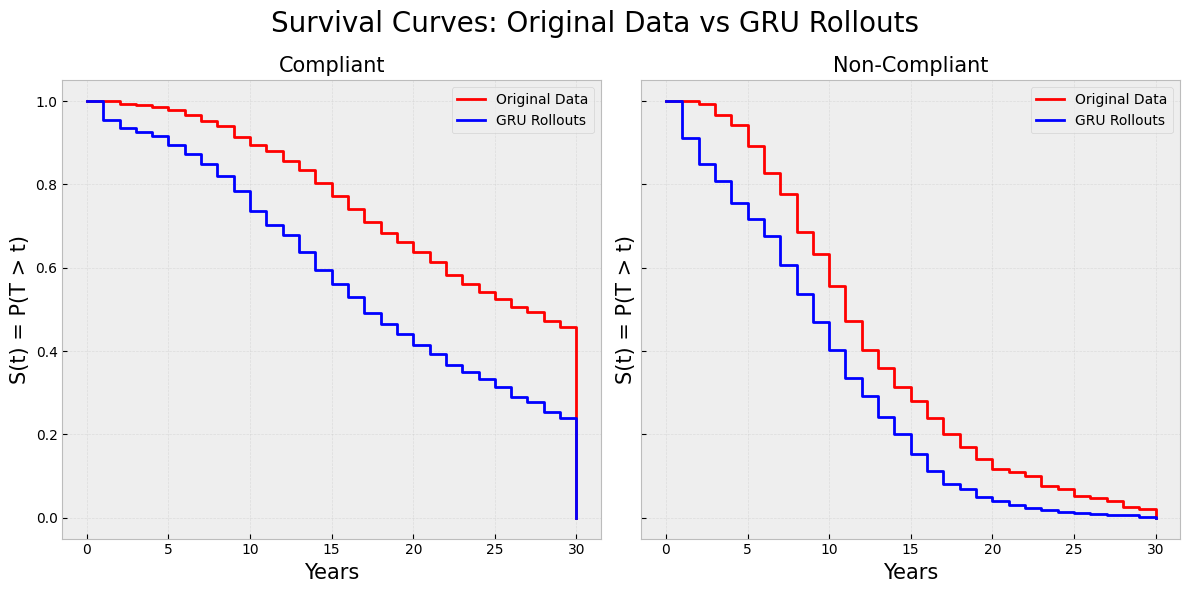

In [ ]:

#calculate survival times
def event_time(seq, T=30):
    idx = np.where(seq == 3)[0]
    if idx.size == 0:
        return T
    return idx[0]


def empirical_survival(times, t_max):
    times = np.asarray(times)
    t = np.arange(0, t_max + 1)
    S = np.array([(times > k).mean() for k in t])
    return t, S

#function that simulates rollouts from stage1, based on learned GRU
@torch.no_grad()
def rollout_patient(model, compliance, T=30, device="cpu"):
    stages = [0]  # start at stage 1
    h = torch.zeros(1, model.cell.hidden_size, device=device)

    #one-hot stage 1 + compliance
    x_t = torch.zeros(1, 5, device=device)
    x_t[0, 0] = 1
    x_t[0, 4] = compliance

    for t in range(T):
        h, _, _ = model.cell(x_t, h)
        logits = model.head(h)
        probs = torch.softmax(logits, dim=-1).cpu().numpy().flatten()

        next_stage = np.random.choice(4, p=probs)
        stages.append(next_stage)

        x_t = torch.zeros(1, 5, device=device)
        x_t[0, next_stage] = 1
        x_t[0, 4] = compliance

        if next_stage == 3:
            stages.extend([3]*(T - t - 1))
            break

    return np.array(stages[:T])

#original data used to train model
obs_times_comp = [event_time(stages_x[i], T=30) for i in range(len(stages_x)) if compliance[i]==1]
obs_times_noncomp = [event_time(stages_x[i], T=30) for i in range(len(stages_x)) if compliance[i]==0]

obs_times_comp = np.array(obs_times_comp)
obs_times_noncomp = np.array(obs_times_noncomp)

#rollout data
num_patients = 100000  
gru_times_comp = np.array([event_time(rollout_patient(model, 1, T=30, device=device), T=30) for _ in range(num_patients)])
gru_times_noncomp = np.array([event_time(rollout_patient(model, 0, T=30, device=device), T=30) for _ in range(num_patients)])


t_max = 30
t_c_obs, S_c_obs = empirical_survival(obs_times_comp, t_max)
t_nc_obs, S_nc_obs = empirical_survival(obs_times_noncomp, t_max)

t_c_gru, S_c_gru = empirical_survival(gru_times_comp, t_max)
t_nc_gru, S_nc_gru = empirical_survival(gru_times_noncomp, t_max)



fig, ax = plt.subplots(1, 2, figsize=(12,6), sharey=True)
plt.style.use('bmh')
#compliant
ax[0].step(t_c_obs, S_c_obs, where="post", label="Original Data", color="red")
ax[0].step(t_c_gru, S_c_gru, where="post", label="GRU Rollouts", color="blue")
ax[0].set_title("Compliant", fontsize=15)
ax[0].set_xlabel("Years", fontsize=15)
ax[0].set_ylabel("S(t) = P(T > t)", fontsize=15)
ax[0].grid(True, alpha=0.3)
ax[0].legend()

#noncompliant
ax[1].step(t_nc_obs, S_nc_obs, where="post", label="Original Data", color="red")
ax[1].step(t_nc_gru, S_nc_gru, where="post", label="GRU Rollouts", color="blue")
ax[1].set_title("Non-Compliant", fontsize=15)
ax[1].set_xlabel("Years", fontsize=15)
ax[1].set_ylabel("S(t) = P(T > t)", fontsize=15)
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.suptitle("Survival Curves: Original Data vs GRU Rollouts", fontsize=20)

plt.tight_layout()
#plt.savefig('survivalcurves.png', dpi=540)